In [97]:
import numpy as np
import torch
from torch.autograd import grad
from torch.optim import Adam
from torch.utils.data import DataLoader, Dataset, TensorDataset
from torch.optim.lr_scheduler import ExponentialLR

import seaborn as sns
from scipy.io import savemat, loadmat
from torch.optim.lr_scheduler import ExponentialLR, MultiStepLR

import torch.nn as nn
import torch.nn.functional as F
import math
import scipy.io as sio
import matplotlib.pyplot as plt
from pinnutils import *
from scipy.linalg import sqrtm
from chebyshev_utils import *
from GEOMLOSS import samples_loss

import matplotlib as mpl
import matplotlib.font_manager
fpaths = matplotlib.font_manager.findSystemFonts()
mpl.rcParams.update({# Use mathtext, not LaTeX
                            'text.usetex': False,
                            # Use the Computer modern font
                            'font.family': 'serif',
                            'font.serif': 'cmr10',
                            'mathtext.fontset': 'cm',
                            # Use ASCII minus
                            'axes.unicode_minus': False,
                            })
matplotlib.rcParams.update({'font.size': 16})


In [98]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


### Simulate toggle-switch and generate data with drift and growth dynamics of the form
### $f_1(x_1, x_2) = a_1 \frac{x_1^n}{k_1^n + x_1^n} + b_1 \frac{k_1^n}{k_1^n + x_2^n}, \quad f_2(x_1, x_2) = a_2 \frac{x_2^n}{k_2^n + x_2^n} + b_2 \frac{k_2^n}{k_2^n + x_1^n}$

### $g(x_1, x_2) = g_r \frac{x_2^2}{1+x_2^2}$


In [100]:
from tqdm import tqdm
def toggle_switch(x,model_params_):
    a1, a2, b1, b2, K1, K2, n = model_params_

    x_ = np.zeros_like(x)
    f = np.zeros_like(x);
    xn = x**n + 0;
    f[:,0] = (a1*(xn[:,0])/(K1**n + xn[:,0])) + b1*(K1**n)/(K1**n + xn[:,1]) # degration is always set to one
    f[:,1] = (a2*(xn[:,1])/(K2**n + xn[:,1])) + b2*(K2**n)/(K2**n + xn[:,0]) # degration is always set to one

    return f

def g_rate(x1,x2,gr):
    """Growth propensity based on gene2 expression."""
    return  gr*( 1.0*(x2**2)/(1+x2**2)  + 0.0*(x1**2)/(1+x1**2) )

def simulate_toggle_with_growth(nsamples, init, Nsnaps, Ndim, seed_, maxiter, model_params, vol, gr, growth_flag=False, reaction_flag=False):
    dt = 0.01; lx = 1
    np.random.seed(seed_)

    xold = init + 0.1*np.random.normal(0,1, (Ndim, nsamples)) #0*np.zeros((Ndim, nsamples))  # shape (Ndim, nsamples)
    tt = np.zeros(Nsnaps)
    samples_fullx = []  # will store a list of arrays with shape (n(t), Ndim)

    steps = int(maxiter / Nsnaps)

    #for snap in range(Nsnaps):
    for snap in tqdm(range(Nsnaps), desc="Snapshots"):
        
        t_snap = snap * steps * dt
        tt[snap] = t_snap

        for _ in range(steps):
        #for _ in tqdm(range(steps), leave=False, desc="Time steps"):
            if(reaction_flag):
                fval = toggle_switch(xold.T, model_params).T  # (Ndim, nsamples)
                noise = np.sqrt(fval + lx * xold) * np.sqrt(dt) * np.random.normal(0, 1, xold.shape)
                xnew = xold + dt * (fval - lx * xold) + (1 / np.sqrt(vol)) * noise

            # Reflect negatives
                xnew = np.where(xnew < 0, xold, xnew)
                xold = xnew + 0;
            else:
                fval = 0.01*toggle_switch(xold.T, model_params).T  # (Ndim, nsamples)
                noise = np.sqrt(fval + 0.1*lx * xold) * np.sqrt(dt) * np.random.normal(0, 1, xold.shape)
                xnew = xold + dt * (fval - 0.1*lx * xold) + (1 / np.sqrt(vol)) * noise

            # Reflect negatives
                xnew = np.where(xnew < 0, xold, xnew)
                xold = xnew + 0;

            if(growth_flag):
                x1 = xold[0]; x2 = xold[1];
                growth_probs = g_rate(x1, x2, gr) * dt
                divide_flags = np.random.rand(x2.shape[0]) < growth_probs
                new_cells = xold[:, divide_flags]  # shape: (Ndim, #dividing cells)

                if new_cells.shape[1] > 0:
                    xold = np.concatenate([xold, new_cells], axis=1)

        samples_fullx.append(xold.T.copy())

    return samples_fullx, tt

#### model_params = [a1, a2, b1, b2, K1, K2, n]
model_params = np.array([2., 2., 1.0, 1.0, 1.0, 1.0, 4.0])

### hyper-parameters of the simulation
Ndim = 2; vol = 4.0; nsamples = 2001; Nsnaps = 5; seed = 0; maxiter = 200; 

gr = 2.0; #growth-rate
growth_flag_ = True; # Set True if growth is modeled
reaction_flag_ = True; # Set True if the reaction is modeled 
init = np.random.uniform(0.25,0.75,(Ndim,nsamples)) + 0;
# init[0,:] = init[0,:] ;
samples_full, tt = simulate_toggle_with_growth(nsamples,init,Nsnaps,Ndim,seed,maxiter,model_params,vol,gr,\
                                               growth_flag=growth_flag_,reaction_flag=reaction_flag_);
samples_full = samples_full[:] 
nsnaps = len(samples_full); 
dt = tt[1] - tt[0];
print(" physical-times of measurement ", tt, " dt ", dt, " nsnaps ", nsnaps)

Snapshots: 100%|██████████| 5/5 [00:00<00:00, 37.13it/s]

 physical-times of measurement  [0.  0.4 0.8 1.2 1.6]  dt  0.4  nsnaps  5


### Population-growth

In [101]:
mass_vec = np.ones((nsnaps,))
for k in range(1,nsnaps):
    mass_vec[k] = len(samples_full[k])/len(samples_full[0])
    print(" # samples at time ", np.round(tt[k],3), ":", len(samples_full[k]))
mass_vec = torch.tensor(mass_vec,dtype=torch.float32,device=device)
print(" ground-truth mass ratio over time ", mass_vec)

 # samples at time  0.4 : 3528
 # samples at time  0.8 : 5276
 # samples at time  1.2 : 8675
 # samples at time  1.6 : 15089
 ground-truth mass ratio over time  tensor([1.0000, 1.4000, 2.0937, 3.4425, 5.9877], device='cuda:0')


### Time-resolved Snapshots

(2520, 2)
(3528, 2)
(5276, 2)
(8675, 2)
(15089, 2)


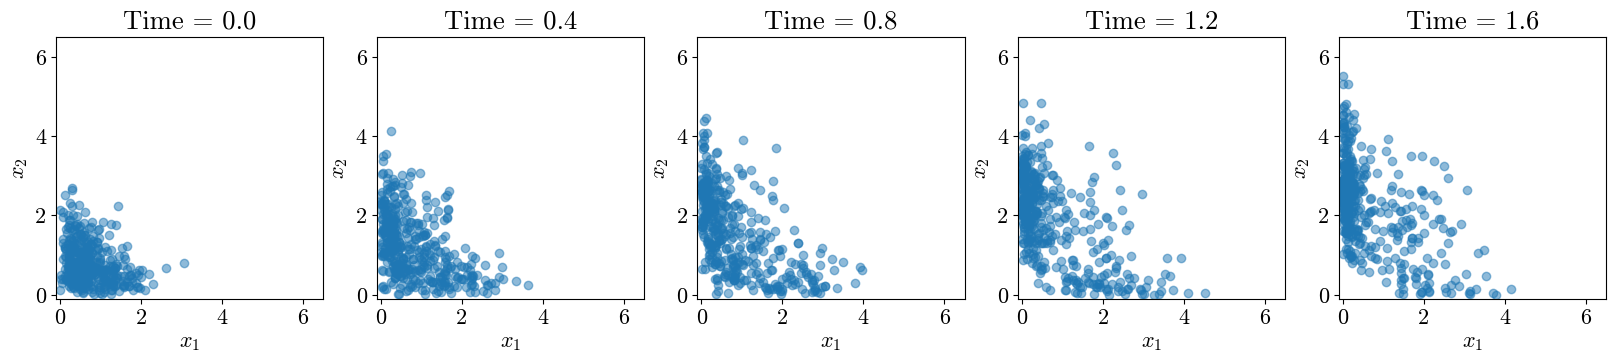

In [103]:
for k in range(0, len(samples_full)):
    plt.subplot(1,len(samples_full),k+1)
    print(samples_full[k].shape)
    ind_s = np.arange(0,samples_full[k].shape[0])
    np.random.shuffle(ind_s)
    plt.scatter(samples_full[k][ind_s[0:400],0],samples_full[k][ind_s[0:400],1],alpha=0.5)
    
    plt.xlim(-0.1,6.5); plt.ylim(-0.1,6.5);
    plt.title(r'Time = '+ str(np.round(tt[k],3)))
    plt.xlabel(r'$x_1$'); plt.ylabel(r'$x_2$')
plt.gcf().set_size_inches(20,3.4)

### Multi-Marginal Optimal Transport

In [104]:
def MMOT_trajectories(samples_):
    nrep = 1;
    print(" # of repetitions ", nrep)

    min_index = np.argmin([arr.shape[0] for arr in samples_])
    nsamples_ = samples_[min_index].shape[0]

    print("Index with fewest samples:", min_index)
    print("Smallest N:", nsamples_)
    
    ### shuffle data to de-correlate the data in time
    Dist_ = np.zeros((len(samples_),nrep,nsamples_,Ndim))   
    for k in range(0, len(samples_)):
        ind_s = np.arange(0,samples_[k].shape[0])
        for j in range(0, nrep):
            np.random.shuffle(ind_s)
            Dist_[k,j,:,:] = samples_[k][ind_s[0:nsamples_],0:Ndim]

    ### Trajectory sampling
    Dist = np.zeros((len(samples_),nrep*nsamples_,Ndim))
    batch_ot_samples  =  torch.tensor(np.zeros((len(samples_),nrep*nsamples_,Ndim)),dtype=torch.float32,device=device)
    for j in range(0, nrep):
        before_ot = torch.tensor(Dist_[:,j,:,0:Ndim],dtype=torch.float32)
        Dist[:,j*nsamples_:(j+1)*nsamples_,:] = Dist_[:,j,:,:]
        before_ot = torch.tensor(Dist[:,j*nsamples_:(j+1)*nsamples_,:],dtype=torch.float32)
        batch_ot_samples[:,j*nsamples_:(j+1)*nsamples_,:] = mmot_trajectories(before_ot,nsamples_,device);

    return Dist, batch_ot_samples
        
Dist, batch_ot_samples = MMOT_trajectories(samples_full) #batch_ot_samples
nsamples = Dist.shape[1] + 0;
print(" nsamples ", nsamples, Dist.shape)
tp = tt + 0;

 # of repetitions  1
Index with fewest samples: 0
Smallest N: 2520
 nsamples  2520 (5, 2520, 2)


### Score Training

In [105]:
def setup_model(Ndim, mean, std, Np, seed_, spectral_flag=True):
    """
    Setup the encoder model and optimizer.
    """
    if(spectral_flag):
        print(" Applying Spectral-Norms ")
        encoder = SpectralNormDNN(
            sizes=[Ndim + 2, Np, Np, Np, Np, Np, Ndim],
            mean=mean.to(device), std=std.to(device),
            seed=seed_, activation=nn.ELU()
        ).to(device)
    else:
        print(" Vanilla DNN ")
        encoder = DNN(
            sizes=[Ndim + 2, Np, Np, Np, Np, Np, Ndim],
            mean=mean.to(device), std=std.to(device),
            seed=seed_, activation=nn.ELU()
        ).to(device)       
    
    print("#parameters:", sum(p.numel() for p in encoder.parameters() if p.requires_grad))
    return encoder, list(encoder.parameters())

Np = 50; spectral_flag = False; L = 10; n_epochs = 50_01; batch_size_score = nsamples + 0;
X_train, X_data, X_mean, X_std, sigma = generate_noisy_training_data_batch(Dist[:,0:nsamples,:], Ndim, tp, L, nsamples, nsnaps, device);
scoreNet, params = setup_model(Ndim, X_mean, X_std, Np, 0, spectral_flag);
start_time = time.time()
    
scoreNet = DSM_training_batched(Ndim, scoreNet, X_train, X_data, sigma, nsnaps, nsamples, L, adp_flag=1, n_epochs=n_epochs, bs=batch_size_score, device=device);

Snapshots:  20%|██        | 1/5 [00:01<00:05,  1.26s/it]

 Done additing noise to Snapshot at time  0.0


Snapshots:  40%|████      | 2/5 [00:02<00:03,  1.26s/it]

 Done additing noise to Snapshot at time  0.4


Snapshots:  60%|██████    | 3/5 [00:03<00:02,  1.26s/it]

...

epoch: 4000 c_: [0.04684719 0.19151102 0.3685263  0.15588124 0.23723419]


Score Training:  90%|█████████ | 4511/5001 [00:43<00:05, 96.66it/s, loss=4.011e+00, lr=1.00e-05] 

epoch: 4500 c_: [0.05537597 0.15608725 0.37564325 0.1548696  0.258024  ]


Score Training: 100%|██████████| 5001/5001 [00:48<00:00, 103.89it/s, loss=4.003e+00, lr=1.00e-06]

epoch: 5000 c_: [0.07098278 0.12499518 0.3690443  0.15093198 0.28404576]


### Score Validation

In [106]:
scoreNet = scoreNet.eval()

def generate_data_DSM(maxiter,infNet,Nsamples,init_,time_,L):
    eps = 1e-4;
    sol = torch.tensor(init_,dtype=torch.float32).to(device)
    sol[:,Ndim+1] = time_
    sigma = geometric_sequence(L);
    for k in range(0,L):
        alpha = eps*((sigma[k]**2)/(sigma[L-1]**2))
        sol[:,Ndim] = sigma[k]
        for t in range(0,500):
            z = torch.normal(0, 1, size=(Nsamples, Ndim)).to(device)
            guru = infNet(sol) 
            sol[:,0:Ndim] = sol[:,0:Ndim] + 0.5*alpha*guru + np.sqrt(alpha)*z
    gen_mean = torch.mean(sol,axis=0)[0:Ndim]      
    sol = sol.cpu().data.numpy().reshape(Nsamples,Ndim+2)
    return sol, gen_mean

def validate_score(scoreNet,Ndim,nsnaps,Dist,L):
    nsamples = Dist.shape[1];
    loss = samples_loss.SamplesLoss("energy")
    maxiter = 100; total_divergence = 0;
    pbar = tqdm(range(int(nsnaps)), desc="Validate", dynamic_ncols=True)
    for tinf in pbar:
        with torch.no_grad():
            infNet = scoreNet.eval()
            init_  = np.random.uniform(1.0,4.0,(nsamples,Ndim+2))  #
            init_[:,0:Ndim] = Dist[tinf,:,0:Ndim]

            sol, gen_mean = generate_data_DSM(maxiter,infNet,nsamples,init_,tp[tinf],L);
            divergence = loss(torch.tensor(sol[:,0:Ndim],dtype=torch.float32,device=device),torch.tensor(Dist[tinf,:,0:Ndim],dtype=torch.float32,device=device))
            total_divergence = divergence + total_divergence
            
            true_mean = (np.mean(Dist[tinf, :, 0:Ndim], axis=0))
            pbar.set_postfix(
                tinf=tinf,
                div=f"{divergence.item():.3e}",
                total=f"{total_divergence:.3e}",
            )

        tqdm.write(f"epoch: {tinf} true_mean: {true_mean} gen_mean: {gen_mean}")
    tqdm.write(f"Total divergence: {total_divergence:.6e}")
    return scoreNet

_ = validate_score(scoreNet,Ndim,nsnaps,Dist[:,:,0:Ndim],L);

Validate:  20%|██        | 1/5 [00:01<00:06,  1.60s/it, div=1.322e-02, tinf=0, total=1.322e-02]

epoch: 0 true_mean: [0.7210021  0.80998835] gen_mean: tensor([0.8191, 0.9267], device='cuda:0')


Validate:  40%|████      | 2/5 [00:03<00:04,  1.59s/it, div=1.354e-03, tinf=1, total=1.457e-02]

epoch: 1 true_mean: [0.85683695 1.16297596] gen_mean: tensor([0.8642, 1.1389], device='cuda:0')


Validate:  60%|██████    | 3/5 [00:04<00:03,  1.59s/it, div=1.489e-03, tinf=2, total=1.606e-02]

epoch: 2 true_mean: [0.85161761 1.53330508] gen_mean: tensor([0.8577, 1.4906], device='cuda:0')


Validate:  80%|████████  | 4/5 [00:06<00:01,  1.59s/it, div=1.355e-03, tinf=3, total=1.741e-02]

epoch: 3 true_mean: [0.79641605 1.8953183 ] gen_mean: tensor([0.7464, 1.9297], device='cuda:0')


Validate: 100%|██████████| 5/5 [00:07<00:00,  1.59s/it, div=4.060e-03, tinf=4, total=2.147e-02]

epoch: 4 true_mean: [0.68804703 2.1742999 ] gen_mean: tensor([0.5981, 2.2374], device='cuda:0')
Total divergence: 2.147365e-02


### Interpolate data to uniform nodes

In [107]:
fac = 1;
uniform_kind = torch.tensor(np.linspace(tp[0],tp[-1],fac*tp.shape[0]))
print(" data nodes ", tp)

data_nodes = torch.tensor(tp,dtype=torch.float32,device=device).expand(Dist.shape[1],-1)
uniform_nodes = torch.tensor(uniform_kind,dtype=torch.float32,device=device).expand(Dist.shape[1],-1)

batch_ot_samples_uniform = interpolate_old2new(batch_ot_samples, data_nodes, uniform_nodes).to(device);

batch_size = int(nsamples/4) + 0; # #batch_ot_samples.shape[1] #*nsamples;
uniform_batch = uniform_kind.expand(batch_size,-1).to(device)

print(" shape of nodes ",  uniform_batch.shape, batch_ot_samples_uniform.shape)

 data nodes  [0.  0.4 0.8 1.2 1.6]
 shape of nodes  torch.Size([630, 5]) torch.Size([5, 2520, 2])


In [108]:
batch_ot_samples_uniform.shape, data_full.shape

(torch.Size([5, 2520, 2]), torch.Size([2197, 10]))

### Estimating strength of regularization based on estimates aggregate velocity estimates

In [109]:
data_full = torch.tensor(uniform_kind,dtype=torch.float32).expand(batch_ot_samples_uniform.shape[1],-1).to(device)
data_highres = uniform_kind.expand(batch_ot_samples_uniform.shape[1],-1).to(device)
best_lam,_,_,_ = select_best_lambda(batch_ot_samples_uniform, batch_ot_samples_uniform.shape[1], data_full, data_full, Ndim, device);
print(" best_lam ", best_lam)

[λ-selection] Initial error: 0.7675
[λ-selection] Best λ (≥80% drop): 0.0010
[λ-selection] Test errors: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[λ-selection] Vel magnitudes: [0.76751888 0.75755113 0.73046207 0.68913162 0.65972716 0.60471129
 0.5832116  0.55819279 0.48697394 0.44803396 0.40529102 0.38075206
 0.30853358 0.26841897]
 best_lam  0.001


### Unbalanced Flow-Matching

In [116]:
def div_neural(drift,inp_,Ndim,inf_lx):
    jac = torch.zeros((drift.shape[0], Ndim, Ndim),device=device)
    div = drift.clone() + 0;
    for i in range(0, Ndim):
        out_ = drift[:,i]
        gradient = grad(outputs=out_, inputs=inp_,
                      grad_outputs=torch.ones_like(out_), 
                      create_graph=True)[0]
        jac[:,i,:] = gradient[:,0:Ndim].clone();
        div[:,i] = inf_lx + gradient[:,i].clone() + 0;
    
    return jac, div

#### Set-up architecture
seed_ = 0; Nf = 25;  spectral_flag = False; TrajNet = True;

kwargs = dict(
        sizes=None,  # fill in below
        seed=seed,
        activation=nn.ELU()
        )

kwargs_growth = dict(
        sizes=None,  # fill in below
        seed=seed,
        activation=nn.ELU()
        )

if spectral_flag:
    cls = SpectralNormDNN
else:
    cls = DNN

if TrajNet:
    kwargs["sizes"] = [Ndim + 1, Nf, Nf, Nf, Nf, Ndim]
else:
    kwargs["sizes"] = [Ndim , Nf, Nf, Nf, Nf, Ndim]
    
kwargs_growth["sizes"] = [Ndim, Nf, Nf, Nf, Nf, 1]

drift_net = cls(**kwargs).to(device)
growth_net = cls(**kwargs_growth).to(device)

print("#parameters:", sum(p.numel() for p in drift_net.parameters() if p.requires_grad) +
                     sum(p.numel() for p in growth_net.parameters() if p.requires_grad))
params_FM = [{'params': drift_net.parameters(), 'lr': 1e-3},
             {'params': growth_net.parameters(), 'lr': 1e-3}]

# Optimizer and scheduler
optimizer_FM = torch.optim.Adam(params_FM)
criterion = nn.MSELoss()
milestones_FM = [[1_000,1500,8_000,15000]]
scheduler_FM = MultiStepLR(optimizer_FM, milestones_FM[0], gamma=0.1)


start_time = time.time()

n_epochs   = 2000
lamb       = 1.0
alpha_ann  = 0.5
lx = 1 

pbar = tqdm(range(n_epochs), desc="Training FM", dynamic_ncols=True)

for epoch in pbar:
    optimizer_FM.zero_grad()

    # ---------------------------------------------------
    # Growth + mass inference
    # ---------------------------------------------------
    growth_ = growth_net(batch_ot_samples_uniform).squeeze(-1)  # (fac*nsnaps, B)

    log_mass = torch.zeros_like(growth_)
    log_mass[0] = np.log(1. / batch_ot_samples_uniform.shape[1])

    for k in range(1, fac * nsnaps):
        log_mass[k] = log_mass[k - 1] + 0.5 * (dt / fac) * (growth_[k] + growth_[k - 1])

    mass_      = torch.exp(log_mass)
    pred_mass  = torch.sum(mass_, axis=1)

    Xtrain, ytrain, weights_ = compute_conditional_distributions_chebyshev_withgrowth(
        batch_ot_samples_uniform, batch_size, mass_,
        uniform_batch, uniform_batch,
        reg_=best_lam, sigma=0.001,
        err_flag=False, device=device
    )

    # ---------------------------------------------------
    # Drift model
    # ---------------------------------------------------
    if TrajNet:
        inp_ = Xtrain[:, torch.cat([torch.arange(0, Ndim), torch.tensor([Ndim+1])])].clone()
        inp_.requires_grad_()
        fold = drift_net(inp_) - lx * Xtrain[:, 0:Ndim]
    else:
        inp_  = Xtrain[:, 0:Ndim].clone()
        inp_.requires_grad_()
        drift = drift_net(inp_)
        jac_d, div_d = div_neural(drift, inp_, Ndim, lx)
        fold = (
            (drift - lx * Xtrain[:, 0:Ndim])
            - (0.5 / vol) * div_d
            - (0.5 / vol) * (drift + lx * Xtrain[:, 0:Ndim]) * scoreNet(Xtrain[:, :])
        ) ### Probability Flow ODE RHS for CLE model

    # ---------------------------------------------------
    # Loss terms
    # ---------------------------------------------------
    res = (fold - ytrain).pow(2).sum(dim=1).reshape(batch_size, fac * nsnaps)

    weights_ = weights_ / torch.sum(weights_, axis=0)[None, :]
    wCFM_obj = torch.mean(weights_ * res, axis=0)
    mass_balance = (pred_mass[::fac] - mass_vec) ** 2

    l1 = torch.sum(wCFM_obj)
    l2 = torch.sum(mass_balance)

    # ---------------------------------------------------
    # Adaptive lambda
    # ---------------------------------------------------
    if epoch % 10 == 0:
        with torch.no_grad():
            std_l1 = loss_grad_std(l1, drift_net, device)
            std_l2 = loss_grad_std(l2, growth_net, device)
            lamb_hat = std_l1 / std_l2
            lamb = (1 - alpha_ann) * lamb + alpha_ann * lamb_hat

    total_loss = l1 + lamb * l2

    if epoch == 0:
        tqdm.write(f"Shapes: Xtrain {Xtrain.shape}, ytrain {ytrain.shape}")

    # ---------------------------------------------------
    # Backprop
    # ---------------------------------------------------
    total_loss.backward()
    optimizer_FM.step()
    scheduler_FM.step()

    # ---------------------------------------------------
    # Progress bar update
    # ---------------------------------------------------
    pbar.set_postfix(
        loss=f"{total_loss.item():.3e}",
        l1=f"{l1.item():.2e}",
        l2=f"{l2.item():.2e}",
        lam=f"{lamb:.3e}",
        lr=f"{optimizer_FM.param_groups[0]['lr']:.2e}",
    )

    # ---------------------------------------------------
    # Occasional diagnostics
    # ---------------------------------------------------
    if epoch % 400 == 0:
        tqdm.write(
            f"[epoch {epoch}] "
            f"inferred mass={torch.sum(mass_, axis=1)[::fac].detach().cpu().numpy()} "
            f"actual mass={mass_vec}"
        )

end_time = time.time()
tqdm.write(f"Total time taken: {end_time - start_time:.2f} seconds")

#parameters: 4153


Training FM:   1%|          | 12/2000 [00:00<00:17, 115.94it/s, l1=1.18e-02, l2=3.83e+00, lam=1.256e-01, loss=4.924e-01, lr=1.00e-03]

Shapes: Xtrain torch.Size([3150, 4]), ytrain torch.Size([3150, 2])
[epoch 0] inferred mass=[1.         0.996889   0.99166304 0.98488057 0.977021  ] actual mass=tensor([1.0000, 1.4000, 2.0937, 3.4425, 5.9877], device='cuda:0')


Training FM:  21%|██▏       | 428/2000 [00:03<00:11, 142.01it/s, l1=2.19e-03, l2=4.55e-02, lam=7.597e-05, loss=2.193e-03, lr=1.00e-03]

[epoch 400] inferred mass=[1.        1.4064918 2.1465416 3.5369077 6.179943 ] actual mass=tensor([1.0000, 1.4000, 2.0937, 3.4425, 5.9877], device='cuda:0')


...

[epoch 1200] inferred mass=[1.        1.3957021 2.1126194 3.452036  5.980825 ] actual mass=tensor([1.0000, 1.4000, 2.0937, 3.4425, 5.9877], device='cuda:0')


Training FM:  81%|████████  | 1621/2000 [00:11<00:02, 136.18it/s, l1=1.78e-03, l2=4.67e-04, lam=1.780e-02, loss=1.793e-03, lr=1.00e-05]

[epoch 1600] inferred mass=[1.        1.3952918 2.1117964 3.4512067 5.9813647] actual mass=tensor([1.0000, 1.4000, 2.0937, 3.4425, 5.9877], device='cuda:0')


Training FM: 100%|██████████| 2000/2000 [00:14<00:00, 139.86it/s, l1=1.96e-03, l2=4.61e-04, lam=7.493e-03, loss=1.966e-03, lr=1.00e-05]

Total time taken: 14.30 seconds


### Validation of inferred force and growth model

 
 
 RMSE in inferred force  0.11764583875530252


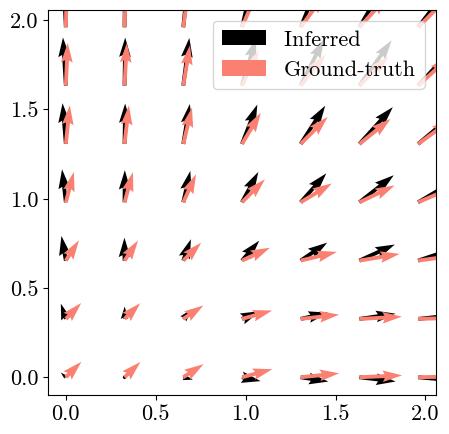

In [122]:
def drift_analytical(x,model_params_):

    a1,a2,b1,b2,K1,K2,n = model_params_
    
    force = np.zeros_like(x);
    x1n = x[:,0]**n; x2n = x[:,1]**n
    force[:,0] = (a1*x1n/((K1**n) + x1n)) + (b1*(K1**n)/((K1**n) + x2n));
    force[:,1] = (a2*x2n/((K2**n) + x2n)) + (b2*(K2**n)/((K2**n) + x1n));
    return force
    
growth_net.eval()
drift_net.eval()

Ngrid = 50; viz_time = 0.5
x_ = np.linspace(0,2,Ngrid); y_ = np.linspace(0,2,Ngrid);
xx_, yy_ = np.meshgrid(x_,y_);

xtest = np.vstack([xx_.flatten(), yy_.flatten(), viz_time*np.ones((Ngrid**2,))]).T
force  = drift_analytical(xtest[:,0:Ndim],model_params) 
xtest = torch.tensor(xtest , dtype=torch.float32, device=device)

if(TrajNet):
    drift  = drift_net(xtest).cpu().data.numpy()
else:
    drift = drift_net(xtest[:,0:Ndim]).cpu().data.numpy()

print(" \n ")
print(" RMSE in inferred force ", np.mean(( (force - drift)**2 ).flatten())/np.mean( (force**2).flatten() )  )

res = 8;
plt.quiver(xx_[::res,::res],yy_[::res,::res],drift[::,0].reshape(Ngrid,Ngrid)[::res,::res],drift[::,1].reshape(Ngrid,Ngrid)[::res,::res],width=0.01,scale=25,label='Inferred ')
plt.quiver(xx_[::res,::res],yy_[::res,::res],force[::,0].reshape(Ngrid,Ngrid)[::res,::res],force[::,1].reshape(Ngrid,Ngrid)[::res,::res],color='salmon',width=0.01,scale=25,label='Ground-truth')
plt.legend(loc='best')
plt.gcf().set_size_inches(5,5)

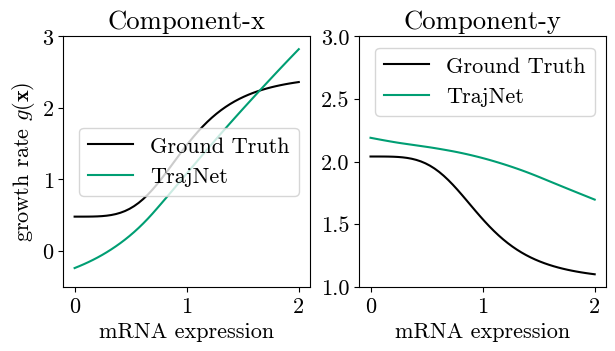

In [123]:
plt.subplot(1,2,1)
plt.plot(y_, force[:,0].reshape(Ngrid,Ngrid)[int(Ngrid/2),:],color='black',label='Ground Truth')
plt.plot(y_, drift[:,0].reshape(Ngrid,Ngrid)[int(Ngrid/2),:],color='#009E73',label='TrajNet')
plt.xlabel('mRNA expression'); plt.ylabel(r'growth rate $g(\mathbf{x})$')
plt.legend(loc='best')
plt.title('Component-x')
plt.ylim(-0.5,3)
plt.gcf().set_size_inches(7,3)

plt.subplot(1,2,2)
plt.plot(y_, force[:,1].reshape(Ngrid,Ngrid)[int(Ngrid/2),:],color='black',label='Ground Truth')
plt.plot(y_, drift[:,1].reshape(Ngrid,Ngrid)[int(Ngrid/2),:],color='#009E73',label='TrajNet')
plt.xlabel('mRNA expression'); #plt.ylabel(r'growth rate $g(\mathbf{x})$')
plt.legend(loc='best')
plt.title('Component-y')
plt.ylim(1,3)
plt.gcf().set_size_inches(7,3.25)

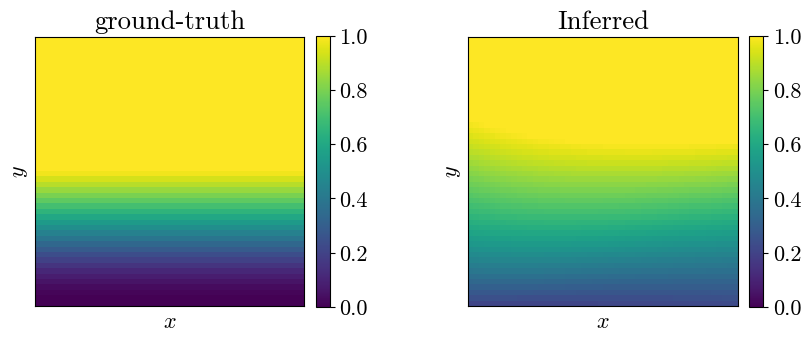

In [119]:
xtest = np.vstack([xx_.flatten(), yy_.flatten()]).T
growth_ = gr*( 1.0*(xtest[:,1]**2)/(1+xtest[:,1]**2)  + 0.0*(xtest[:,0]**2)/(1+xtest[:,0]**2) )

plt.subplot(1,2,1)
plt.imshow(growth_.reshape(Ngrid,Ngrid),origin='lower',vmin=0,vmax=1)
plt.title('ground-truth')
plt.xticks([]); plt.yticks([]);
plt.xlabel('$x$'); plt.ylabel('$y$')
plt.colorbar(pad=0.04, fraction=0.046)

plt.subplot(1,2,2)
xtest_torch = torch.tensor(xtest,dtype=torch.float32).to(device)
growth_inf = growth_net(xtest_torch).squeeze(-1).cpu().data.numpy()
plt.imshow(growth_inf.reshape(Ngrid,Ngrid),origin='lower',vmin=0,vmax=1)
plt.title('Inferred')
plt.xticks([]); plt.yticks([]);
plt.xlabel('$x$'); plt.ylabel('$y$')
plt.colorbar(pad=0.04, fraction=0.046)

print(" RMSE ", np.mean(( (growth_inf - growth_inf)**2 ).flatten())/np.mean( (force**2).flatten() )  )

plt.tight_layout()
plt.gcf().set_size_inches(9,4)

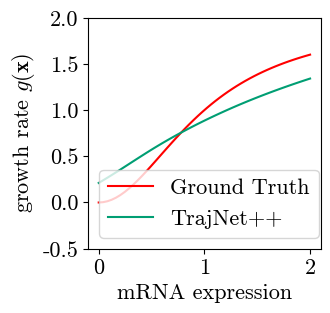

In [120]:
plt.plot(y_, growth_.reshape(Ngrid,Ngrid)[:,int(Ngrid/2)],color='red',label='Ground Truth')
plt.plot(y_, growth_inf.reshape(Ngrid,Ngrid)[:,int(Ngrid/2)],color='#009E73',label='TrajNet++')
plt.xlabel('mRNA expression'); plt.ylabel(r'growth rate $g(\mathbf{x})$')
plt.legend(loc='best')
plt.ylim(-0.5,2)
plt.gcf().set_size_inches(3,3)